# **House Price Prediction**

## **Introduction**

House Price Prediction is a machine learning project that predicts the price of a house using its features. In this project, the data is cleaned, analyzed, and preprocessed before building a machine learning model. The main goal is to predict house prices accurately based on the given information.

### **TASK 1**

### **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt

### **Connect Google Drive**

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


###**Load the Dataset**

In [ ]:
data=pd.read_csv(r"/content/drive/MyDrive/Project__/data.csv")

####**Data**

In [ ]:
data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


###**Basic checks**

In [ ]:
data.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
data.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [ ]:
data.shape

(1460, 81)

In [ ]:
data.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


**Dataset Overview**

1. The dataset contains 1460 rows and 81 columns.

2. It includes both numerical and categorical columns.

3. The target column is SalePrice, which represents the selling price of a house.

4. The dataset contains information such as house size, quality, number of rooms, garage details, and construction year.

5. Some columns contain missing values, which need to be handled during data preprocessing.

6. The numerical features have different value ranges, indicating variation in house characteristics.

7. The dataset contains enough records to perform data analysis and build a machine learning model.

8. Overall, the dataset provides useful information for understanding the factors that affect house prices and predicting the selling price of a house.


**Statistical Analysis**

1. The average house selling price is 180,921, with prices ranging from 34,900 to 755,000.

2. Most houses have an overall quality rating of 6 and an overall condition rating of 5.

3. The average lot size is about 10,517 square feet, but some houses have much larger lots.

4. Most houses were built around 1971 and remodeled around 1985.

5. The average above-ground living area is about 1,515 square feet.

6. Most houses have 3 bedrooms, 2 full bathrooms, and 2 garage spaces.

7. The mean and median differ in some columns, indicating that the data is slightly skewed.

8. Some numerical features have a large range between the minimum and maximum values, suggesting the presence of outliers.

###**Data Preprocessing**

###**Check Missing Values**

In [ ]:
data.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,259
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


Some columns contain missing values that need to be handled.

In [ ]:
data.isnull().sum()[data.isnull().sum() > 0]

,0
LotFrontage,259
Alley,1369
MasVnrType,872
MasVnrArea,8
BsmtQual,37
BsmtCond,37
BsmtExposure,38
BsmtFinType1,37
BsmtFinType2,38
Electrical,1


**Insights**

1. PoolQC contains the highest number of missing values.
2. Alley, Fence, and MiscFeature also contain significant missing values.
3. Missing values mainly indicate the absence of a feature.
4. Appropriate imputation techniques are required before model training.

####**Drop Columns with More Than 50% Missing Values**

In [ ]:
data.drop(['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType'],axis=1,inplace=True)

In [ ]:
num_cols=data.select_dtypes(include=['int64','float64']).columns
continuous=[]
discrete=[]
for col in num_cols:
    if data[col].nunique()>25:
        continuous.append(col)
    else:
        discrete.append(col)

For Continuous Data

In [ ]:
plt.figure(figsize=(20,15))
i = 0
for col in continuous:
    plt.subplot(8,5,i+1)
    sns.histplot(data[col], kde=True)
    plt.title(col)
    i = i + 1
plt.tight_layout()
plt.show()

In [ ]:
num_cols = data.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    if data[col].isnull().sum() > 0:
        if abs(data[col].skew()) < 0.5:
            data[col] = data[col].fillna(data[col].mean())
        else:
            data[col] = data[col].fillna(data[col].median())

For Discrete Data

In [ ]:
plt.figure(figsize=(20,15))
i = 0
for col in discrete:
    plt.subplot(8,4,i+1)
    sns.countplot(x=data[col])
    plt.title(col)
    plt.xticks(rotation=90)
    i = i + 1
plt.tight_layout()
plt.show()

In [ ]:
data[col]=data[col].fillna(data[col].mode()[0])

####**Handle Missing Values in Cateogorical Columns with mode**

In [ ]:
cat_cols = data.select_dtypes(include=['object']).columns
for col in cat_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

In [ ]:
data.isnull().sum()

,0
Id,0
MSSubClass,0
MSZoning,0
LotFrontage,0
LotArea,0
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [ ]:
data.isnull().sum()[data.isnull().sum() > 0]

,0


###**Check Duplicate Values**

In [ ]:
data.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset, indicating good data quality.

###**Drop "Id" Column**

In [ ]:
data=data.drop('Id',axis=1)

The Id column is only a unique identifier and does not help in predicting house prices.

###**Check Distribution of Numerical Columns**

In [ ]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')


####**Identify Continuous Numerical Columns**

In [ ]:
continuous_cols=[]
for col in num_cols:
    if data[col].nunique()>25:
        continuous_cols.append(col)
continuous_cols

['LotFrontage',
 'LotArea',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'GrLivArea',
 'GarageYrBlt',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 'ScreenPorch',
 'SalePrice']

#### **Distribution of Continuous Numerical Columns**

In [ ]:

plt.figure(figsize=(20,20))
i = 0
for col in continuous_cols:
    plt.subplot(10, 4, i+1)
    sns.histplot(x=data[col], kde=True)
    plt.title(f"Histogram of {col}")
    i=i+1
plt.tight_layout()
plt.show()

#### **Handle Outliers in Normally Distributed Columns Using 3 Standard Deviation Method**

In [ ]:
std_cols = ['LotFrontage','GrLivArea','GarageArea']
for col in std_cols:
  mean=data[col].mean()
  std=data[col].std()
  lower_limit=mean-(3*std)
  upper_limit=mean+(3*std)
  data.loc[(data[col]<lower_limit)|(data[col]>upper_limit),col]=mean

###**Outlier Handling**

In [ ]:

plt.figure(figsize=(20,20))
i = 0
for col in num_cols:
    plt.subplot(10, 4, i+1)
    sns.boxplot(x=data[col])
    plt.title(f"Boxplot of {col}")
    i=i+1
plt.tight_layout()
plt.show()

#### **Handle Outliers in Skewed Numerical Columns Using IQR Method**

In [ ]:
cols=['MSSubClass','LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'SalePrice']
for i in cols:
    print(i)
    Q1=data[i].quantile(0.25)
    Q3=data[i].quantile(0.75)
    print('Q1',Q1)
    print('Q3',Q3)
    IQR=data[i].quantile(0.75)-data[i].quantile(0.25)
    print('IQR',IQR)
    lower_limit=Q1-1.5*IQR
    print('lower_limit',lower_limit)
    upper_limit=Q3+1.5*IQR
    print('upper_limit',upper_limit)
    #len(data[i].loc[data[i]>upper_limit])
    #len(data.loc[data[i]<lower_limit])
    s=(len(data.loc[data[i]>upper_limit])+len(data.loc[data[i]<lower_limit]))/len(data)
    print(s)
    if s<0.05:
        data.loc[data[i]>upper_limit,i]=data[i].median()
        data.loc[data[i]<lower_limit,i]=data[i].median()
    else:
        print("outlier is not handled in",i)
    print("")

MSSubClass
Q1 20.0
Q3 70.0
IQR 50.0
lower_limit -55.0
upper_limit 145.0
0.07054794520547945
outlier is not handled in MSSubClass

LotFrontage
Q1 60.0
Q3 78.0
IQR 18.0
lower_limit 33.0
upper_limit 105.0
0.07054794520547945
outlier is not handled in LotFrontage

LotArea
Q1 7553.5
Q3 11601.5
IQR 4048.0
lower_limit 1481.5
upper_limit 17673.5
0.04726027397260274

OverallQual
Q1 5.0
Q3 7.0
IQR 2.0
lower_limit 2.0
upper_limit 10.0
0.0013698630136986301

OverallCond
Q1 5.0
Q3 6.0
IQR 1.0
lower_limit 3.5
upper_limit 7.5
0.08561643835616438
outlier is not handled in OverallCond

YearBuilt
Q1 1954.0
Q3 2000.0
IQR 46.0
lower_limit 1885.0
upper_limit 2069.0
0.004794520547945206

MasVnrArea
Q1 0.0
Q3 164.25
IQR 164.25
lower_limit -246.375
upper_limit 410.625
0.06712328767123288
outlier is not handled in MasVnrArea

BsmtFinSF1
Q1 0.0
Q3 712.25
IQR 712.25
lower_limit -1068.375
upper_limit 1780.625
0.004794520547945206

BsmtFinSF2
Q1 0.0
Q3 0.0
IQR 0.0
lower_limit 0.0
upper_limit 0.0
0.1143835616438356

The following columns were not handled for outliers

MSSubClass, LotFrontage, OverallCond, MasVnrArea, BsmtFinSF2, BsmtHalfBath, OpenPorchSF, EnclosedPorch, and ScreenPorch.

### **Create a Copy of the Dataset**

In [ ]:
x=data.copy()

###**EDA-Exploratory Data Analysis**

####**Univariate Analysis**

####**Univariate Analysis for Continuous Columns**

In [ ]:
num_cols=x.select_dtypes(include=['int64','float64']).columns
continuous=[]
discrete=[]
for col in num_cols:
    if x[col].nunique()>25:
        continuous.append(col)
    else:
        discrete.append(col)

In [ ]:

plt.figure(figsize=(20,20))
i = 0
for col in continuous:
    plt.subplot(5, 4, i+1)
    sns.histplot(x=x[col], kde=True)
    plt.title(f"Histogram of {col}")
    i = i + 1
plt.tight_layout()
plt.show()

**Insights**

1. Most size-related features are positive-skewed → many average-sized homes and a few very large homes.
2. Newer houses and garages appear more often (more homes built after 1950).
3. Several features have many zero values (2nd floor, porches, second finished basement) → many homes do not include these features.
4. Living area and total basement area are closer to a normal distribution around common house sizes.
5. SalePrice is slightly right-skewed → most houses are in the middle price range, with a few expensive properties.
6. Multiple variables show outliers, especially lot size, porch area, and basement-related features.


####**Univariate Analysis for Discrete Columns**

In [ ]:

plt.figure(figsize=(20,20))
i = 0
for col in discrete:
    plt.subplot(5,4,i+1)
    sns.countplot(x=x[col])
    plt.xticks(rotation=90)
    plt.title(f"Countplot of {col}")
    i = i + 1
plt.tight_layout()
plt.show()

**Insights**

1. Most houses have average to good construction quality (OverallQual concentrated around 5–7).
2. The dataset contains many missing/zero-dominant features (PoolArea, 3SsnPorch, LowQualFinSF, MiscVal), suggesting feature reduction opportunities.
3. Most homes include 3 bedrooms, 1 kitchen, and 1–2 bathrooms, showing a standard residential layout.
4. Garage capacity is mainly 2 cars, indicating a common housing pattern.
5. Property sales peak during mid-year (May–July).
6. Several categorical features are highly imbalanced and may require preprocessing before modeling.


####**Univariate Analysis of Categorical Columns**

In [ ]:
cat_cols=x.select_dtypes(include=['object']).columns
plt.figure(figsize=(20,25))
i = 0
for col in cat_cols:
    plt.subplot(9,5,i+1)
    sns.countplot(x=x[col])
    plt.xticks(rotation=90)
    plt.title(f"Countplot of {col}")
    i=i+1
plt.tight_layout()
plt.show()

**Insights**

1. Most properties belong to residential zoning categories and are concentrated in common neighborhood types.

2. Most houses have regular lot shapes, flat land contours, and access to paved streets.

3. Exterior quality, basement quality, kitchen quality, and garage quality are mainly rated in the average to good range.

4. Central air conditioning and standard electrical systems are present in the majority of homes.

5. Attached and detached garages are the dominant garage types, with many garages being unfinished or partially finished.

6. Most property transactions occurred under normal sale conditions, showing stable market patterns.

7. Several categorical variables show strong class imbalance, highlighting the need for feature selection and preprocessing before modeling.



####**Bivariate Analysis**

####**Bivariate Analysis of Continuous Numerical Data**

**Continuous data vs SalePrice**

In [ ]:
continuous_cols = []
for col in num_cols:
    if x[col].nunique() > 25:
        continuous_cols.append(col)
plt.figure(figsize=(20,20))
i=0
for col in continuous_cols:
  if col!="SalePrice":
    plt.subplot(5,4,i+1)
    sns.scatterplot(x=x[col],y=x["SalePrice"])
    plt.title(f"{col} vs SalePrice")
    i=i+1
plt.tight_layout()
plt.show()

**Insights**

1. GrLivArea showed the strongest positive relationship with SalePrice, indicating larger living areas generally lead to higher house prices.

2. TotalBsmtSF, 1stFlrSF, and GarageArea also displayed clear positive correlations with SalePrice.

3. Newer houses and recently remodeled houses (YearBuilt, YearRemodAdd) tended to have higher sale prices.

4. LotArea and LotFrontage had only a moderate impact on SalePrice compared to interior living space features.

5. Features such as OpenPorchSF, EnclosedPorch, ScreenPorch, and BsmtFinSF2 showed weak relationships with SalePrice.

6. Several variables contained outliers and non-linear patterns, suggesting the need for feature engineering and outlier handling before modeling.


####**Bivariate Analysis of Discrete Data**

In [ ]:

plt.figure(figsize=(20,20))
i = 0
for col in discrete:
    plt.subplot(5,4,i+1)
    sns.boxplot(x=x[col], y=x['SalePrice'])
    plt.xticks(rotation=90)
    plt.title(f"{col} vs SalePrice")
    i = i + 1
plt.tight_layout()
plt.show()

**Insights**

1. OverallQual showed the strongest impact on SalePrice — houses with higher quality ratings had significantly higher prices.

2. Larger homes with more total rooms (TotRmsAbvGrd), full bathrooms, and garage capacity generally achieved higher sale prices.

3. GarageCars displayed a clear positive relationship with SalePrice, making parking capacity an important pricing factor.

4. Houses with fireplaces tended to have higher median sale prices compared to homes without fireplaces.

5. Bedroom count and basement bathroom features showed only moderate influence on SalePrice.

6. SalePrice remained relatively stable across months and years sold, indicating limited seasonal or yearly price variation.

7. Several discrete features contained outliers, suggesting the need for outlier handling before predictive modeling.


####**Bivariate Analysis of Categorical Data**

**Categorical data vs SalePrice**

In [ ]:
cat_cols=x.select_dtypes(include=['object']).columns
plt.figure(figsize=(30,35))
i = 0
for col in cat_cols:
    plt.subplot(11,4,i+1)
    sns.barplot(x=x[col],y=x["SalePrice"],hue='Street',data=x)
    plt.xticks(rotation=90)
    plt.title(f"Barplot of {col}")
    i=i+1
plt.tight_layout()
plt.show()

**Insights**

1. Houses with excellent quality ratings generally have higher sale prices.

2. Houses with better basement quality tend to have higher sale prices.

3. Houses with central air conditioning usually have higher sale prices.

4. Certain neighborhoods have noticeably higher sale prices than others.

5. Houses with finished garages tend to sell at higher prices.

6. Houses with better kitchen quality generally have higher sale prices.

7. Houses sold under normal conditions make up most of the sales.

8. Features such as quality, neighborhood, basement quality, garage type, and kitchen quality have a noticeable impact on sale price.


###**Encoding**

In [ ]:
for col in cat_cols:
  print(data[col].value_counts())
  print("")

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

Street
Pave    1454
Grvl       6
Name: count, dtype: int64

LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

LandContour
Lvl    1311
Bnk      63
HLS      50
Low      36
Name: count, dtype: int64

Utilities
AllPub    1459
NoSeWa       1
Name: count, dtype: int64

LotConfig
Inside     1052
Corner      263
CulDSac      94
FR2          47
FR3           4
Name: count, dtype: int64

LandSlope
Gtl    1382
Mod      65
Sev      13
Name: count, dtype: int64

Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
SWISU       25
StoneBr     25
Blmngtn     17
MeadowV     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count,

In [ ]:
from sklearn.preprocessing import LabelEncoder
lc=LabelEncoder()

####**One-Hot Encoding**

In [ ]:
data['Street'].value_counts()

,count
Street,
Pave,1454
Grvl,6


In [ ]:
data['Street']=pd.get_dummies(data['Street'],drop_first=True).astype(int)

In [ ]:
data['Street'].value_counts()

,count
Street,
1,1454
0,6


####**Label Encoding**

In [ ]:
label_cols = [
    'MSZoning',
    'LotShape',
    'LandContour',
    'Utilities',
    'LotConfig'
]
for col in label_cols:
    data[col] = lc.fit_transform(data[col])

In [ ]:
data.head().T

,0,1,2,3,4
MSSubClass,60,20,60,70,60
MSZoning,3,3,3,3,3
LotFrontage,65.0,80.0,68.0,60.0,84.0
LotArea,8450.0,9600.0,11250.0,9550.0,14260.0
Street,1,1,1,1,1
...,...,...,...,...,...
MoSold,2,5,9,2,12
YrSold,2008,2007,2008,2006,2008
SaleType,WD,WD,WD,WD,WD
SaleCondition,Normal,Normal,Normal,Abnorml,Normal


# Manual_encoding

In [ ]:
man_cols = [
    'LandSlope',
    'BldgType',
    'ExterQual',
    'ExterCond',
    'BsmtQual',
    'BsmtCond',
    'BsmtExposure',
    'HeatingQC',
    'CentralAir',
    'Electrical',
    'KitchenQual',
    'GarageQual',
    'GarageCond',
    'PavedDrive'
]
man_cols

['LandSlope',
 'BldgType',
 'ExterQual',
 'ExterCond',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'GarageQual',
 'GarageCond',
 'PavedDrive']

In [ ]:

plt.figure(figsize=(25,20))
i = 0
for col in man_cols:
    plt.subplot(9,5,i+1)
    sns.boxplot(x=data[col],y=data['SalePrice'])
    plt.xticks(rotation=90)
    plt.title(col)
    i += 1
plt.tight_layout()
plt.show()

In [ ]:
man_en={'LandSlope':{'Gtl':0,'Mod':1,'Sev':2},
        'BldgType':{'2fmCon':0,'Duplex':1,'Twnhs':2,'TwnhsE':3,'1Fam':4},
        'ExterQual':{'Ex':3,'Gd':2,'TA':1,'Fa':0},
        'ExterCond':{'Ex':4,'Gd':3,'TA':2,'Fa':1,'Po':0},
        'BsmtQual':{'Ex':3,'Gd':2,'TA':1,'Fa':0},
        'BsmtCond':{'Gd':3,'TA':2,'Fa':1,'Po':0},
        'BsmtExposure':{'Gd':3,'Av':2,'Mn':1,'No':0},
        'HeatingQC':{'Po':4,'Ex':3,'Gd':2,'TA':1,'Fa':0},
        'CentralAir':{'Y':1,'N':0},
        'Electrical':{'Mix':4,'SBrkr':3,'FuseA':2,'FuseF':1,'FuseP':0},
        'KitchenQual':{'Ex':3,'Gd':2,'TA':1,'Fa':0},
        'GarageQual':{'Po':4,'Ex':3,'Gd':2,'TA':1,'Fa':0},
        'GarageCond':{'Ex':4,'Gd':3,'TA':2,'Fa':1,'Po':0},
        'PavedDrive':{'Y':2,'P':1,'N':0}
        }
data = data.replace(man_en)

####**Frequency Encoding**

In [ ]:
frequency_cols = [
    'Neighborhood',
    'Condition1',
    'Condition2',
    'HouseStyle',
    'RoofStyle',
    'RoofMatl',
    'Exterior1st',
    'Exterior2nd',
    'Foundation',
    'BsmtFinType1',
    'BsmtFinType2',
    'Heating',
    'Functional',
    'FireplaceQu',
    'GarageType',
    'GarageFinish',
    'SaleType',
    'SaleCondition'
]

plt.figure(figsize=(20,20))
i=0
for col in frequency_cols:
    plt.subplot(10,4,i+1)
    sns.countplot(x=data[col])
    plt.xticks(rotation=90)
    plt.title(f"Countplot of {col}")
    i=i+1
plt.tight_layout()
plt.show()

In [ ]:
for col in frequency_cols:
    print(f"\nColumn: {col}")
    print(data[col].value_counts())


Column: Neighborhood
Neighborhood
NAmes      225
CollgCr    150
OldTown    113
Edwards    100
Somerst     86
Gilbert     79
NridgHt     77
Sawyer      74
NWAmes      73
SawyerW     59
BrkSide     58
Crawfor     51
Mitchel     49
NoRidge     41
Timber      38
IDOTRR      37
ClearCr     28
SWISU       25
StoneBr     25
Blmngtn     17
MeadowV     17
BrDale      16
Veenker     11
NPkVill      9
Blueste      2
Name: count, dtype: int64

Column: Condition1
Condition1
Norm      1260
Feedr       81
Artery      48
RRAn        26
PosN        19
RRAe        11
PosA         8
RRNn         5
RRNe         2
Name: count, dtype: int64

Column: Condition2
Condition2
Norm      1445
Feedr        6
Artery       2
RRNn         2
PosN         2
PosA         1
RRAn         1
RRAe         1
Name: count, dtype: int64

Column: HouseStyle
HouseStyle
1Story    726
2Story    445
1.5Fin    154
SLvl       65
SFoyer     37
1.5Unf     14
2.5Unf     11
2.5Fin      8
Name: count, dtype: int64

Column: RoofStyle
RoofSty

In [ ]:
for col in frequency_cols:
    freq = data[col].value_counts()
    data[col] = data[col].map(freq)

####**Checking after Encoding**

In [ ]:
data.head().T

,0,1,2,3,4
MSSubClass,60.0,20.0,60.0,70.0,60.0
MSZoning,3.0,3.0,3.0,3.0,3.0
LotFrontage,65.0,80.0,68.0,60.0,84.0
LotArea,8450.0,9600.0,11250.0,9550.0,14260.0
Street,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...
MoSold,2.0,5.0,9.0,2.0,12.0
YrSold,2008.0,2007.0,2008.0,2006.0,2008.0
SaleType,1267.0,1267.0,1267.0,1267.0,1267.0
SaleCondition,1198.0,1198.0,1198.0,101.0,1198.0


###**Correlation Analysis**

In [ ]:
data.corr()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
MSSubClass,1.000000,0.035900,-0.411269,-0.433102,-0.024969,0.119289,-0.002940,-0.022844,0.075910,-0.025672,...,-0.012037,NaN,-0.026030,NaN,NaN,-0.013585,-0.021407,0.024031,0.022733,-0.057853
MSZoning,0.035900,1.000000,-0.130131,-0.085447,0.087654,0.061887,-0.017854,-0.001192,-0.009895,-0.022055,...,0.115509,NaN,0.019089,NaN,NaN,-0.031496,-0.020628,0.162017,0.147626,-0.222300
LotFrontage,-0.411269,-0.130131,1.000000,0.588380,-0.049166,-0.138210,0.004794,0.000403,-0.168058,0.016038,...,-0.013316,NaN,0.062466,NaN,NaN,0.018189,-0.003193,-0.094032,-0.052431,0.311190
LotArea,-0.433102,-0.085447,0.588380,1.000000,-0.006064,-0.293777,0.025698,0.042741,-0.183391,0.023538,...,-0.022727,NaN,0.093993,NaN,NaN,0.005780,-0.019429,-0.051935,-0.025513,0.366502
Street,-0.024969,0.087654,-0.049166,-0.006064,1.000000,-0.010224,0.115995,0.001682,0.013960,-0.179360,...,0.023082,NaN,-0.033160,NaN,NaN,0.003690,-0.025043,0.008635,0.000115,0.044036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MoSold,-0.013585,-0.031496,0.018189,0.005780,0.003690,-0.033455,-0.011599,-0.051552,0.018902,0.007072,...,-0.028887,NaN,0.023217,NaN,NaN,1.000000,-0.145721,-0.085607,-0.069878,0.068543
YrSold,-0.021407,-0.020628,-0.003193,-0.019429,-0.025043,0.036449,0.020507,0.023353,-0.005992,-0.002305,...,-0.009916,NaN,0.010694,NaN,NaN,-0.145721,1.000000,0.075423,0.130481,-0.027262
SaleType,0.024031,0.162017,-0.094032,-0.051935,0.008635,0.019911,-0.011862,-0.069934,-0.005978,0.073321,...,0.047923,NaN,0.022328,NaN,NaN,-0.085607,0.075423,1.000000,0.609095,-0.108560
SaleCondition,0.022733,0.147626,-0.052431,-0.025513,0.000115,-0.007348,0.047147,-0.055928,0.007113,-0.006353,...,0.024641,NaN,0.011231,NaN,NaN,-0.069878,0.130481,0.609095,1.000000,-0.022653


###**Heatmap**

In [ ]:
data = data.loc[:, data.nunique() > 1]

In [ ]:
plt.figure(figsize=(300,300))
sns.heatmap(data.corr(),annot=True,annot_kws={'size':50})
plt.xticks(fontsize=45,rotation=50)
plt.yticks(fontsize=45,rotation=50)
plt.show()

GarageArea and GarageCars are highly correlated.

In [ ]:
data[['GarageCars','GarageArea','SalePrice']].corr()

,GarageCars,GarageArea,SalePrice
GarageCars,1.000000,0.877192,0.590731
GarageArea,0.877192,1.000000,0.581198
SalePrice,0.590731,0.581198,1.000000


drop "GarageArea" column

In [ ]:
data.drop('GarageArea',axis=1,inplace=True)

###**Store Preprocessed Data**

In [ ]:
data.to_csv('/content/drive/MyDrive/Project__/pre_data.csv')

In [ ]:
pre_data=pd.read_csv('/content/drive/MyDrive/Project__/pre_data.csv')

In [ ]:
pre_data

,Unnamed: 0,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0,60,3,65.0,8450.0,1,3,3,0,4,...,2,0,61,0,0,2,2008,1267,1198,208500
1,1,20,3,80.0,9600.0,1,3,3,0,2,...,2,298,0,0,0,5,2007,1267,1198,181500
2,2,60,3,68.0,11250.0,1,0,3,0,4,...,2,0,42,0,0,9,2008,1267,1198,223500
3,3,70,3,60.0,9550.0,1,0,3,0,0,...,2,0,35,272,0,2,2006,1267,101,140000
4,4,60,3,84.0,14260.0,1,0,3,0,2,...,2,192,84,0,0,12,2008,1267,1198,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1455,60,3,62.0,7917.0,1,3,3,0,4,...,2,0,40,0,0,8,2007,1267,1198,175000
1456,1456,20,3,85.0,13175.0,1,3,3,0,4,...,2,349,0,0,0,2,2010,1267,1198,210000
1457,1457,70,3,66.0,9042.0,1,3,3,0,4,...,2,0,60,0,0,5,2010,1267,1198,266500
1458,1458,20,3,68.0,9717.0,1,3,3,0,4,...,2,366,0,112,0,4,2010,1267,1198,142125


In [ ]:
pre_data.drop(['Unnamed: 0'],axis=1,inplace=True)

In [ ]:
pre_data

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,3,65.0,8450.0,1,3,3,0,4,0,...,2,0,61,0,0,2,2008,1267,1198,208500
1,20,3,80.0,9600.0,1,3,3,0,2,0,...,2,298,0,0,0,5,2007,1267,1198,181500
2,60,3,68.0,11250.0,1,0,3,0,4,0,...,2,0,42,0,0,9,2008,1267,1198,223500
3,70,3,60.0,9550.0,1,0,3,0,0,0,...,2,0,35,272,0,2,2006,1267,101,140000
4,60,3,84.0,14260.0,1,0,3,0,2,0,...,2,192,84,0,0,12,2008,1267,1198,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,3,62.0,7917.0,1,3,3,0,4,0,...,2,0,40,0,0,8,2007,1267,1198,175000
1456,20,3,85.0,13175.0,1,3,3,0,4,0,...,2,349,0,0,0,2,2010,1267,1198,210000
1457,70,3,66.0,9042.0,1,3,3,0,4,0,...,2,0,60,0,0,5,2010,1267,1198,266500
1458,20,3,68.0,9717.0,1,3,3,0,4,0,...,2,366,0,112,0,4,2010,1267,1198,142125


###**Prepare Data for Modeling**

####**Define Features and Target**

In [ ]:
x=pre_data.drop('SalePrice',axis=1)
y=pre_data['SalePrice']

In [ ]:
x

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,ScreenPorch,MoSold,YrSold,SaleType,SaleCondition
0,60,3,65.0,8450.0,1,3,3,0,4,0,...,2,2,0,61,0,0,2,2008,1267,1198
1,20,3,80.0,9600.0,1,3,3,0,2,0,...,2,2,298,0,0,0,5,2007,1267,1198
2,60,3,68.0,11250.0,1,0,3,0,4,0,...,2,2,0,42,0,0,9,2008,1267,1198
3,70,3,60.0,9550.0,1,0,3,0,0,0,...,2,2,0,35,272,0,2,2006,1267,101
4,60,3,84.0,14260.0,1,0,3,0,2,0,...,2,2,192,84,0,0,12,2008,1267,1198
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,3,62.0,7917.0,1,3,3,0,4,0,...,2,2,0,40,0,0,8,2007,1267,1198
1456,20,3,85.0,13175.0,1,3,3,0,4,0,...,2,2,349,0,0,0,2,2010,1267,1198
1457,70,3,66.0,9042.0,1,3,3,0,4,0,...,2,2,0,60,0,0,5,2010,1267,1198
1458,20,3,68.0,9717.0,1,3,3,0,4,0,...,2,2,366,0,112,0,4,2010,1267,1198


In [ ]:
y

,SalePrice
0,208500
1,181500
2,223500
3,140000
4,250000
...,...
1455,175000
1456,210000
1457,266500
1458,142125


####**Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.shape

(1168, 68)

In [ ]:
x_test.shape

(292, 68)

In [ ]:
y_train.shape

(1168,)

In [ ]:
y_test.shape

(292,)

####**Feature Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [ ]:
y_train_scaled=scaler.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled=scaler.transform(y_test.values.reshape(-1,1))

###**Model Building**

####**Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression
lrmodel=LinearRegression()
lrmodel.fit(x_train_scaled,y_train_scaled)

LinearRegression()

In [ ]:
y_pred1=lrmodel.predict(x_test_scaled)

In [ ]:
lrmodel.coef_

array([[ 5.42194280e-02, -7.43597194e-02,  4.61581183e-03,
         7.35470370e-02, -2.34334127e-03, -1.69772217e-02,
         4.28261642e-03, -3.98600783e-03, -2.01997660e-02,
         6.02054142e-02, -2.98986314e-02,  2.76912415e-02,
         1.43106531e-02,  8.24708313e-02,  8.84599891e-03,
         1.26531658e-01,  1.15460048e-01,  1.92943327e-01,
         6.60451494e-02,  2.22982286e-02, -1.21161044e-02,
         1.09801613e-02,  1.90974912e-04, -6.65994721e-02,
         6.03278591e-03, -2.86019141e-02,  1.21851841e-02,
        -4.03918138e-02,  4.69084825e-02, -2.00946325e-02,
         2.39296765e-02,  6.34887088e-02,  2.82343211e-02,
         2.94345481e-02,  4.41096900e-02,  2.05736560e-01,
         2.90629046e-03,  1.97799787e-02,  1.77173951e-02,
        -5.21209110e-03,  6.01437196e-03,  1.54632121e-01,
         2.70715602e-01,  4.30576000e-02,  2.21960654e-03,
         1.24957214e-03, -5.38321815e-02, -2.88259276e-02,
         3.17869538e-02, -1.50718486e-02,  6.40498361e-0

In [ ]:
lrmodel.intercept_

array([9.98095145e-16])

####**Evaluation**

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [ ]:
MSE=mean_squared_error(y_test_scaled,y_pred1)
MSE

0.2975489771695583

In [ ]:
MAE=mean_absolute_error(y_test_scaled,y_pred1)
MAE

0.3725040669420281

In [ ]:
rmse=np.sqrt(MSE)
rmse

np.float64(0.5454805011818097)

In [ ]:
r2_score(y_test_scaled,y_pred1)

0.727848940217253

In [ ]:
adj_r2=1-(1-0.7281975083526138)*(292-69)/(292-69-1)
adj_r2

0.7269731728046526

---

####**Lasso Regression**

In [ ]:
from sklearn.linear_model import Lasso
lasso=Lasso(alpha=0.1)
lasso.fit(x_train_scaled,y_train_scaled)
y_pred2=lasso.predict(x_test_scaled)
mse=mean_squared_error(y_test_scaled,y_pred2)

print(f'mean squared error:{mse}')
print(f'MAE:{mean_absolute_error(y_test_scaled,y_pred2)}')
print(f'RMSE:{np.sqrt(mean_squared_error(y_test_scaled,y_pred2))}')
print(f"R-squared:{r2_score(y_test_scaled,y_pred2)}")
print(f'coefficients:',lasso.coef_)
print(f'intercept:',lasso.intercept_)

mean squared error:0.3635351115461772
MAE:0.4287627811500825
RMSE:0.6029387295125245
R-squared:0.6674951908197878
coefficients: [-0.         -0.          0.          0.02783963 -0.         -0.
  0.         -0.         -0.          0.         -0.          0.
  0.          0.          0.          0.19928434  0.          0.09355858
  0.07938302  0.         -0.          0.          0.         -0.
  0.          0.          0.          0.          0.          0.
  0.          0.         -0.          0.          0.          0.11076333
  0.          0.00402585  0.00875101  0.          0.          0.
  0.26228283  0.          0.          0.          0.          0.
  0.03081723  0.          0.          0.04924056 -0.          0.
  0.         -0.04705495  0.05053055  0.          0.          0.
  0.          0.         -0.          0.          0.         -0.
  0.          0.        ]
intercept: [-6.24005647e-16]


---

####**Ridge Rgression**

In [ ]:
from sklearn.linear_model import Ridge
ridge=Ridge(alpha=0.1)
ridge.fit(x_train,y_train)
y_pred3=ridge.predict(x_test)
print(f'mean squared error:{mean_squared_error(y_test_scaled,y_pred3)}')
print(f'MAE:{mean_absolute_error(y_test_scaled,y_pred3)}')
print(f'RMSE:{np.sqrt(mean_squared_error(y_test_scaled,y_pred3))}')
print(f'R-squared:{r2_score(y_test_scaled,y_pred3)}')
print(f'coefficients:',ridge.coef_)
print(f'intercept:',ridge.intercept_)

mean squared error:30265016004.99976
MAE:166189.79462671926
RMSE:173968.4339327102
R-squared:-27681682048.30117
coefficients: [ 7.32147547e+01 -7.00269056e+03  1.46364440e+01  1.36094013e+00
 -2.25561133e+03 -6.89074014e+02  3.55126303e+02 -7.03009254e+03
 -7.01936471e+02  1.29523295e+04 -2.69923236e+01  3.77995905e+00
  5.90229359e+00  5.33958071e+03  2.11667639e+00  5.37822812e+03
  5.94119580e+03  3.70062740e+02  1.83007042e+02  3.45099433e+00
 -3.85865934e+00  3.58752296e+00  6.38376431e-02 -2.21604677e+01
  6.06481487e+02 -4.52904166e+03  4.07122661e+00 -3.40715979e+03
  9.29427054e+03 -1.11833663e+03  9.59527104e+00  8.62261520e+00
  4.10013678e+00  1.06838851e+01  6.23054691e+00  3.46366060e+01
  7.75182437e-01  1.18025353e+03  3.94901624e+03 -7.56259685e+02
  1.00011828e+00  2.03347995e+01  3.54587395e+01  4.80281437e+03
  5.27168389e+02  1.34808784e+02 -6.17572769e+03 -2.36678319e+03
  2.75743790e+03 -6.00759064e+02  1.06694448e+01  6.38368007e+03
  3.01664450e+00  7.29701930e

---

####**KNN Regressor**

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

####**K-value**

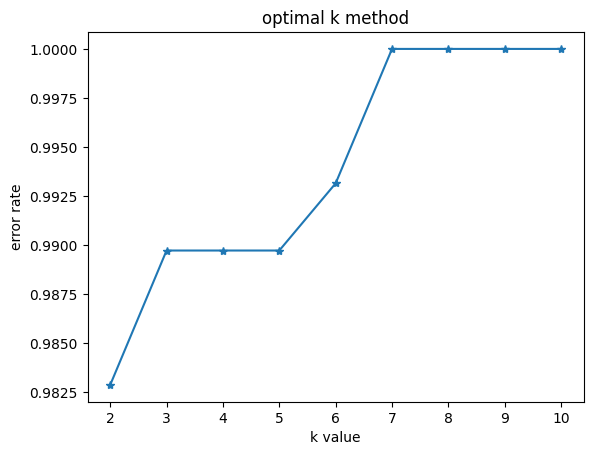

In [ ]:
error_rate=[]
for i in range(2,11):
  kn_model=KNeighborsRegressor(n_neighbors=i)
  kn_model.fit(x_train_scaled,y_train_scaled)
  y_pred4=kn_model.predict(x_test_scaled)
  error_rate.append(np.mean(y_pred4!=y_test_scaled))
plt.plot(range(2,11),error_rate,marker='*')
plt.title("optimal k method")
plt.xlabel("k value")
plt.ylabel("error rate")
plt.show()

In [ ]:
kn_model=KNeighborsRegressor(n_neighbors=3)

In [ ]:
kn_model.fit(x_train_scaled,y_train_scaled)

KNeighborsRegressor(n_neighbors=3)

In [ ]:
y_pred4=kn_model.predict(x_test_scaled)

####**Evaluation**

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [ ]:
MSE=mean_squared_error(y_test_scaled,y_pred4)
MSE

0.36149807599113637

In [ ]:
MAE=mean_absolute_error(y_test_scaled,y_pred4)
MAE

0.40063725561723784

In [ ]:
r2_score(y_test_scaled,y_pred4)

0.6693583509300765

In [ ]:
adj_r2=1-(1-0.6687037347542616)*(292-1)/(292-69-1)
adj_r2

0.5657332739346401

---

####**Support Vector Regressor(SVR)**

In [ ]:
from sklearn.svm import SVR
svregressor=SVR()
svregressor.fit(x_train_scaled,y_train_scaled)

SVR()

In [ ]:
y_pred5=svregressor.predict(x_test_scaled)

####**Evaluation**

In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [ ]:
MSE=mean_squared_error(y_test_scaled,y_pred5)
MSE

0.27899797278563454

In [ ]:
MAE=mean_absolute_error(y_test_scaled,y_pred5)
MAE

0.3458059681748786

In [ ]:
r2_score(y_test_scaled,y_pred5)

0.744816484690586

In [ ]:
adj_r2=1-(1-0.7448545357886918)*(292-1)/(292-69-1)
adj_r2

0.6655525671824742

---

####**Random Forest Regressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
random_model=RandomForestRegressor()
random_model.fit(x_train_scaled,y_train_scaled)

RandomForestRegressor()

In [ ]:
y_pred6=random_model.predict(x_test_scaled)

####**Evaluation**

In [ ]:
MSE=mean_squared_error(y_test_scaled,y_pred6)
MSE

0.2532452661987151

In [ ]:
MAE=mean_absolute_error(y_test_scaled,y_pred6)
MAE

0.33917470651334103

In [ ]:
r2_score(y_test_scaled,y_pred6)

0.7683710149617836

In [ ]:
adj_r2=1-(1-0.7672634759151893)*(292-1)/(292-69-1)
adj_r2

0.6949264481590995

---

####**Decision Tree Regressor**

In [ ]:
from sklearn.tree import DecisionTreeRegressor
dt_model=DecisionTreeRegressor()
dt_model.fit(x_train_scaled,y_train_scaled)

DecisionTreeRegressor()

In [ ]:
y_pred7=dt_model.predict(x_test_scaled)

####**Evaluation**

In [ ]:
MSE=mean_squared_error(y_test_scaled,y_pred7)
MSE

0.469770295518494

In [ ]:
MAE=mean_absolute_error(y_test_scaled,y_pred7)
MAE

0.4450619875672588

In [ ]:
r2_score(y_test_scaled,y_pred7)

0.5703279339220919

In [ ]:
adj_r2=1-(1-0.5745198546099654)*(292-1)/(292-69-1)
adj_r2

0.442276025637387

---

####**Bagging Regressor**

In [ ]:
from sklearn.ensemble import BaggingRegressor
bag_model=BaggingRegressor(estimator=svregressor,n_estimators=50)
bag_model.fit(x_train_scaled,y_train_scaled)

BaggingRegressor(estimator=SVR(), n_estimators=50)

In [ ]:
y_pred8=bag_model.predict(x_test_scaled)

####**Evaluation**

In [ ]:
MSE=mean_squared_error(y_test_scaled,y_pred8)
MSE

0.2854445871251912

In [ ]:
MAE=mean_absolute_error(y_test_scaled,y_pred8)
MAE

0.35275353356568767

In [ ]:
r2_score(y_test_scaled,y_pred8)

0.7389201346469385

In [ ]:
adj_r2=1-(1-0.7376394980885135)*(292-1)/(292-69-1)
adj_r2

0.6560950177646732

---

####**Gradient Boosting Regressor**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model=GradientBoostingRegressor(n_estimators=120)
gb_model.fit(x_train_scaled,y_train_scaled)

GradientBoostingRegressor(n_estimators=120)

In [ ]:
y_pred9=gb_model.predict(x_test_scaled)

####**Evaluation**

In [ ]:
MSE=mean_squared_error(y_test_scaled,y_pred9)
MSE

0.2266108846543689

In [ ]:
MAE=mean_absolute_error(y_test_scaled,y_pred9)
MAE

0.3162413330902685

In [ ]:
r2_score(y_test_scaled,y_pred9)

0.7927319629741213

In [ ]:
adj_r2=1-(1-0.7934419218229832)*(292-1)/(292-69-1)
adj_r2

0.7292414380652619

---

####**XGB Regressor**

In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor
xgb_model=XGBRegressor()
xgb_model.fit(x_train_scaled,y_train_scaled)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred10=xgb_model.predict(x_test_scaled)

####**Evaluation**

In [ ]:
MSE=mean_squared_error(y_test_scaled,y_pred10)
MSE

0.2548423111713478

In [ ]:
MAE=mean_absolute_error(y_test_scaled,y_pred10)
MAE

0.32793683840817905

In [ ]:
r2_score(y_test_scaled,y_pred10)

0.7669102891143712

In [ ]:
adj_r2=1-(1-0.7669102891143712)*(292-1)/(292-69-1)
adj_r2

0.6944634870823514

---

####**After selecting the models**

| Model | R2 Score |
| ------------------ | ------- |
| Gradient Boosting | 0.7927319629741213  |
| Random Forest Regressor | 0.7683710149617836  |




Cross Validation $ Hyperparameter Tuning

####**Gradient Boosting Regressor**

####**Cross Validation Score**

In [ ]:
from sklearn.model_selection import cross_val_score
cv_score=cross_val_score(gb_model,x_train_scaled,y_train_scaled,cv=5,scoring='r2')
print("CV Scores:",cv_score)
print("Mean CV Score:",np.mean(cv_score))
print("Std:",cv_score.std())

CV Scores: [0.69036157 0.75714934 0.76178506 0.70370215 0.76914523]
Mean CV Score: 0.7364286688170409
Std: 0.032667625419523734


####**Hyperparameter Tuning**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
params = {
    'n_estimators':[100,120,150,200],
    'learning_rate':[0.01,0.05,0.1,0.2],
    'max_depth':[3,4,5,6],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4],
    'subsample':[0.8,0.9,1.0]
}
random = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(),
    param_distributions=params,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
random.fit(x_train_scaled, y_train_scaled)
print("Best Parameters:")
print(random.best_params_)
print("Best CV Score:")
print(random.best_score_)

Best Parameters:
{'subsample': 0.9, 'n_estimators': 120, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 3, 'learning_rate': 0.1}
Best CV Score:
0.7456409360349363


In [ ]:
gb_model=GradientBoostingRegressor(subsample=0.9, n_estimators=120, min_samples_split=10, min_samples_leaf=4, max_depth=3, learning_rate=0.1)
gb_model.fit(x_train_scaled,y_train_scaled)

GradientBoostingRegressor(min_samples_leaf=4, min_samples_split=10,
                          n_estimators=120, subsample=0.9)

In [ ]:
y_pred11=gb_model.predict(x_test_scaled)

In [ ]:
MSE=mean_squared_error(y_test_scaled,y_pred11)
MSE

0.22809875839476484

In [ ]:
MAE=mean_absolute_error(y_test_scaled,y_pred11)
MAE

0.3135067988542886

In [ ]:
r2_score(y_test_scaled,y_pred11)

0.7913710898193098

---

####**Random Forest Regressor**

####**Cross Validation Score**

In [ ]:
from sklearn.model_selection import cross_val_score
cv_score=cross_val_score(random_model,x_train_scaled,y_train_scaled,cv=5,scoring='r2')
print("CV Scores:",cv_score)
print("Mean CV Score:",np.mean(cv_score))
print("Std:",cv_score.std())

CV Scores: [0.73016197 0.73094822 0.77659797 0.67931994 0.75746846]
Mean CV Score: 0.7348993122254339
Std: 0.03278800210374985


####**HyperParameter Tuning**

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
params = {
    'n_estimators':[100,120,150,200],
    'max_depth':[3,4,5,6,10,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}
random = RandomizedSearchCV(
    estimator=RandomForestRegressor(),
    param_distributions=params,
    n_iter=20,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
random.fit(x_train_scaled, y_train_scaled)
print("Best Parameters:")
print(random.best_params_)
print("Best CV Score:")
print(random.best_score_)

Best Parameters:
{'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}
Best CV Score:
0.7367758511878477


In [ ]:
random_model=RandomForestRegressor(n_estimators=150, min_samples_split=2, min_samples_leaf=1, max_depth=None)
random_model.fit(x_train_scaled,y_train_scaled)

RandomForestRegressor(n_estimators=150)

In [ ]:
y_pred12=random_model.predict(x_test_scaled)

In [ ]:
MSE=mean_squared_error(y_test_scaled,y_pred12)
MSE

0.24779219736734692

In [ ]:
MAE=mean_absolute_error(y_test_scaled,y_pred12)
MAE

0.3356663906085457

In [ ]:
r2_score(y_test_scaled,y_pred12)

0.7733586256591628

---

####**After Tuning**

| Model | R2 Score |
| ------------------ | ------- |
| Gradient Boosting | 0.7913710898193098 |
| Random Forest Regressor | 0.7733586256591628 |




**Best Model** - Gradient Boosting Regressor

# HOUSE PRICE PREDICTION

## TASK 1: COMPLETE DATA ANALYSIS REPORT

### 1. Objective

The objective of this project is to develop a machine learning model that predicts the selling price of houses based on different property features. The project also aims to analyze the dataset, identify important factors affecting house prices, preprocess the data, and compare different regression algorithms to select the best-performing model.

---

## 2. Dataset Overview

**Dataset:** Ames Housing Dataset

**Target Variable:** `SalePrice`

**Total Records:** 1460

**Total Columns:** 81 initially

**Problem Type:** Supervised Machine Learning – Regression

The dataset contains information about residential properties such as house quality, living area, lot size, number of rooms, bathrooms, garage details, basement area, construction year, neighborhood, and other property characteristics.

### Dataset Overview – Insights

1. The dataset contains **1460 rows and 81 columns**.
2. It contains both **numerical and categorical features**.
3. `SalePrice` is the target variable representing the selling price of a house.
4. The dataset contains information about house size, quality, rooms, garages, basements, construction year, and location-related features.
5. Some columns contain missing values that require preprocessing.
6. The numerical features have different ranges and distributions.
7. The dataset provides sufficient information for exploratory analysis and machine learning.
8. Overall, the dataset is suitable for understanding the factors affecting house prices and building a regression model.

---

## 3. Statistical Analysis

Statistical analysis was performed using descriptive statistics to understand the numerical characteristics of the dataset.

### Statistical Analysis – Insights

1. The average house selling price is approximately **180,921**, while prices range from **34,900 to 755,000**.
2. The average overall quality rating is around **6**, while the overall condition is around **5**.
3. The average lot area is approximately **10,517 square feet**.
4. Houses were built across different years, with the average construction year around **1971**.
5. The average above-ground living area is approximately **1,515 square feet**.
6. Most houses have around **3 bedrooms** and **2 full bathrooms**.
7. The dataset contains differences between mean and median values for several variables, indicating skewness.
8. Some variables have large minimum-to-maximum ranges, indicating the presence of extreme values and outliers.

---

# 4. Data Preprocessing

Data preprocessing was performed before applying machine learning algorithms.

### 4.1 Missing Value Analysis

Missing values were checked using `isnull().sum()`.

The following columns contained a large number of missing values:

* `PoolQC`
* `MiscFeature`
* `Alley`
* `Fence`
* `MasVnrType`

These columns were removed because they contained a large proportion of missing values.

### Missing Value Insights

1. `PoolQC` contained the highest number of missing values.
2. `Alley`, `Fence`, and `MiscFeature` also contained many missing values.
3. Some missing values represented the absence of a particular house feature.
4. Appropriate imputation was performed for the remaining missing values.

---

## 4.2 Handling Numerical Missing Values

Numerical missing values were handled based on the distribution of the feature.

* Mean was used for approximately normally distributed numerical variables.
* Median was used for skewed numerical variables.

The skewness of numerical columns was checked before selecting the appropriate method.

---

## 4.3 Handling Categorical Missing Values

Missing values in categorical columns were replaced using the **mode**, which represents the most frequently occurring category.

After preprocessing, the dataset was checked again to ensure that missing values were handled.

---

## 4.4 Duplicate Check

Duplicate records were checked using:

`data.duplicated().sum()`

No duplicate records were found.

Therefore, the dataset did not contain duplicate observations.

---

## 4.5 Removing Unnecessary Column

The `Id` column was removed because it is only a unique identifier and does not provide useful information for predicting house prices.

---

# 5. Outlier Detection and Handling

Outliers were identified using:

* Box plots
* Interquartile Range (IQR)
* 3 Standard Deviation method

### 5.1 3 Standard Deviation Method

The 3-standard-deviation method was applied to approximately normally distributed features such as:

* `LotFrontage`
* `GrLivArea`
* `GarageArea`

Values outside the range of:

**Mean ± 3 × Standard Deviation**

were replaced with the mean value.

---

### 5.2 IQR Method

The IQR method was used for skewed numerical features.

The formula used was:

**IQR = Q3 − Q1**

Lower Limit:

**Q1 − 1.5 × IQR**

Upper Limit:

**Q3 + 1.5 × IQR**

When the percentage of outliers was below the selected threshold, the extreme values were replaced with the median.

Some variables were not modified because their outlier proportion was higher than the selected threshold.

The columns for which outliers were not handled include:

* `MSSubClass`
* `LotFrontage`
* `OverallCond`
* `MasVnrArea`
* `BsmtFinSF2`
* `BsmtHalfBath`
* `OpenPorchSF`
* `EnclosedPorch`
* `ScreenPorch`

---

# 6. Exploratory Data Analysis

Exploratory Data Analysis was performed using univariate and bivariate analysis.

---

## 6.1 Univariate Analysis

Univariate analysis was performed separately for:

* Continuous numerical variables
* Discrete numerical variables
* Categorical variables

### Continuous Numerical Features

Histogram plots with KDE were used to understand the distribution of continuous variables.

### Insights

1. Many size-related features are positively skewed.
2. Most houses have average-sized living areas, while a smaller number have very large areas.
3. Several variables contain many zero values because not all houses have features such as second floors, porches, or finished basements.
4. `GrLivArea` and `TotalBsmtSF` show distributions around common house sizes.
5. `SalePrice` is slightly right-skewed.
6. Several numerical variables contain extreme values.

---

## 6.2 Univariate Analysis of Discrete Variables

Count plots were used to understand the frequency of discrete numerical features.

### Insights

1. Most houses have average to good construction quality.
2. `OverallQual` is mainly concentrated around quality levels 5–7.
3. Most houses have approximately 3 bedrooms.
4. Most properties have 1 kitchen and 1–2 bathrooms.
5. Garage capacity is mainly concentrated around 2 cars.
6. Some features such as `PoolArea`, `3SsnPorch`, and `MiscVal` contain many zero values.
7. Several variables show class imbalance.

---

## 6.3 Univariate Analysis of Categorical Variables

Count plots were used to analyze categorical variables.

### Insights

1. Most properties belong to common residential zoning categories.
2. Regular lot shapes are common.
3. Most properties have paved street access.
4. Exterior, basement, kitchen, and garage quality are mainly in the average to good range.
5. Central air conditioning is present in most houses.
6. Attached and detached garages are the dominant garage types.
7. Most transactions occurred under normal sale conditions.
8. Some categorical features show strong class imbalance.

---

# 7. Bivariate Analysis

Bivariate analysis was performed to study the relationship between individual features and `SalePrice`.

---

## 7.1 Continuous Numerical Features vs SalePrice

Scatter plots were used to analyze the relationship between continuous numerical variables and house prices.

### Insights

1. `GrLivArea` showed a strong positive relationship with `SalePrice`.
2. Houses with larger above-ground living areas generally have higher prices.
3. `TotalBsmtSF` also showed a positive relationship with house price.
4. `1stFlrSF` and `GarageArea` showed positive relationships with `SalePrice`.
5. `YearBuilt` and `YearRemodAdd` indicate that newer or recently remodeled houses tend to have higher prices.
6. `LotArea` and `LotFrontage` showed a comparatively moderate relationship.
7. Porch-related features such as `OpenPorchSF`, `EnclosedPorch`, and `ScreenPorch` showed weaker relationships.
8. Several variables showed outliers and non-linear patterns.

---

## 7.2 Discrete Features vs SalePrice

Box plots were used to compare house prices across different discrete feature values.

### Insights

1. `OverallQual` has a strong impact on `SalePrice`.
2. Higher-quality houses generally have significantly higher selling prices.
3. Houses with more rooms generally have higher prices.
4. Houses with more full bathrooms generally have higher prices.
5. `GarageCars` has a clear positive relationship with house price.
6. Houses with fireplaces tend to have higher median selling prices.
7. Bedroom count and basement bathroom features show comparatively moderate effects.
8. Several discrete variables contain outliers.

---

## 7.3 Categorical Features vs SalePrice

Bar plots were used to compare average house prices across categorical variables.

### Insights

1. Houses with better exterior quality generally have higher prices.
2. Better basement quality is associated with higher prices.
3. Houses with central air conditioning generally have higher prices.
4. Different neighborhoods have noticeably different price levels.
5. Finished or better-quality garages are associated with higher prices.
6. Better kitchen quality is associated with higher house prices.
7. Quality, neighborhood, basement quality, garage-related features, and kitchen quality have noticeable effects on price.

---

# 8. Feature Encoding

Categorical features were converted into numerical form before model training.

The following encoding techniques were used:

### 8.1 One-Hot Encoding

One-hot encoding was applied to the `Street` column.

### 8.2 Label Encoding

Label encoding was applied to:

* `MSZoning`
* `LotShape`
* `LandContour`
* `Utilities`
* `LotConfig`

### 8.3 Manual Encoding

Manual encoding was performed for ordered categorical features such as:

* `LandSlope`
* `BldgType`
* `ExterQual`
* `ExterCond`
* `BsmtQual`
* `BsmtCond`
* `BsmtExposure`
* `HeatingQC`
* `CentralAir`
* `Electrical`
* `KitchenQual`
* `GarageQual`
* `GarageCond`
* `PavedDrive`

### 8.4 Frequency Encoding

Frequency encoding was applied to:

* `Neighborhood`
* `Condition1`
* `Condition2`
* `HouseStyle`
* `RoofStyle`
* `RoofMatl`
* `Exterior1st`
* `Exterior2nd`
* `Foundation`
* `BsmtFinType1`
* `BsmtFinType2`
* `Heating`
* `Functional`
* `FireplaceQu`
* `GarageType`
* `GarageFinish`
* `SaleType`
* `SaleCondition`

This converted categorical values into numerical frequencies.

---

# 9. Correlation Analysis

Correlation analysis was performed after preprocessing and encoding.

A correlation heatmap was created to identify relationships between numerical features.

A high correlation was observed between:

* `GarageCars`
* `GarageArea`

Since these two features contained highly similar information, `GarageArea` was removed from the dataset to reduce redundancy.

---

# 10. Data Splitting

The preprocessed dataset was divided into training and testing datasets.

* **Training Data:** 80%
* **Testing Data:** 20%
* **Random State:** 42

With 1460 records:

* Training records = **1168**
* Testing records = **292**

---

# 11. Feature Scaling

Standardization was applied using `StandardScaler`.

The features and target variable were scaled before training the regression models.

The scaler was fitted using the training data and then applied to the testing data.

---

# TASK 2(a): ROBUST MACHINE LEARNING ALGORITHM FOR HOUSE PRICE PREDICTION

## 1. Objective

The objective of this task is to develop a machine learning regression model that can accurately predict house prices. Multiple regression algorithms were trained and evaluated, and the best-performing model was selected.

---

## 2. Machine Learning Models Implemented

The notebook implemented the following regression models:

1. Linear Regression
2. Lasso Regression
3. Ridge Regression
4. K-Nearest Neighbors Regressor
5. Support Vector Regressor
6. Random Forest Regressor
7. Decision Tree Regressor
8. Bagging Regressor
9. Gradient Boosting Regressor
10. XGBoost Regressor

These models were compared based mainly on their R² scores and prediction errors.

---

## 3. Model Evaluation Metrics

The following evaluation metrics were used:

### Mean Squared Error (MSE)

MSE measures the average squared difference between actual and predicted values.

### Mean Absolute Error (MAE)

MAE measures the average absolute difference between actual and predicted values.

### Root Mean Squared Error (RMSE)

RMSE is the square root of MSE and represents the prediction error in the same scale as the target.

### R² Score

R² measures how well the model explains the variation in house prices.

A higher R² value indicates better predictive performance.

---

# 4. Model Performance

The main models selected for comparison in the notebook were Gradient Boosting and Random Forest.

| Model                       |  Test R² Score |
| --------------------------- | -------------: |
| Gradient Boosting Regressor | **0.79273196** |
| Random Forest Regressor     | **0.76837101** |

Based on the test results, **Gradient Boosting Regressor** achieved the highest R² score.

---

# 5. Best Model

### Selected Model: Gradient Boosting Regressor

**Test R² Score: 0.79273196**

The Gradient Boosting Regressor performed better than the other selected models on the test dataset.

It was selected because:

1. It achieved the highest test R² score.
2. It captured non-linear relationships between house features and price.
3. It provided better prediction performance compared with Random Forest.
4. It produced a lower MAE than several other models.
5. It provided feature importance values that helped identify the major factors affecting house prices.

---

# 6. Hyperparameter Tuning

Randomized Search with 5-fold cross-validation was used to tune the Gradient Boosting Regressor.

The parameters considered included:

* `n_estimators`
* `learning_rate`
* `max_depth`
* `min_samples_split`
* `min_samples_leaf`
* `subsample`

### Best Parameters

The RandomizedSearchCV process selected:

| Parameter           | Best Value |
| ------------------- | ---------: |
| `n_estimators`      |        120 |
| `learning_rate`     |        0.1 |
| `max_depth`         |          3 |
| `min_samples_split` |         10 |
| `min_samples_leaf`  |          4 |
| `subsample`         |        0.9 |

### Best Cross-Validation Score

**0.74564094**

---

## 7. Gradient Boosting After Tuning

After applying the selected hyperparameters, the Gradient Boosting model achieved:

* **MAE:** 0.31350680
* **R² Score:** 0.79137109

The tuned model remained the best-performing model overall, although its test R² was slightly lower than the original Gradient Boosting model.

---

# 8. Random Forest Hyperparameter Tuning

RandomizedSearchCV was also applied to the Random Forest Regressor.

### Best Parameters

| Parameter           | Best Value |
| ------------------- | ---------: |
| `n_estimators`      |        150 |
| `max_depth`         |       None |
| `min_samples_split` |          2 |
| `min_samples_leaf`  |          1 |

### Best Cross-Validation Score

**0.73677585**

After tuning, Random Forest achieved:

**Test R² Score: 0.77335863**

---

# 9. Before and After Hyperparameter Tuning

| Model             |  Before Tuning |   After Tuning |
| ----------------- | -------------: | -------------: |
| Gradient Boosting | **0.79273196** |     0.79137109 |
| Random Forest     |     0.76837101 | **0.77335863** |

The Gradient Boosting Regressor still provided the highest test R² score after the comparison.

---

# 10. Final Prediction Workflow

The complete prediction workflow is:

1. Load the house price dataset.
2. Perform basic data checks.
3. Identify missing values.
4. Handle missing values.
5. Remove unnecessary columns.
6. Detect and handle outliers.
7. Perform univariate and bivariate EDA.
8. Encode categorical variables.
9. Perform correlation analysis.
10. Remove highly redundant features.
11. Split the dataset into training and testing sets.
12. Scale the data.
13. Train multiple regression models.
14. Evaluate model performance.
15. Perform hyperparameter tuning.
16. Select the best model.
17. Use the selected Gradient Boosting model for house price prediction.

---

# TASK 2(b): RELATIONSHIP BETWEEN HOUSE FEATURES AND HOUSE PRICE

## Objective

The objective of this task is to identify the most important features that influence house prices.

Both correlation analysis and feature importance from the Gradient Boosting Regressor were considered.

---

## Top 10 Factors Affecting House Prices

According to the feature importance analysis in the notebook, the top factors are:

1. **OverallQual**
2. **GrLivArea**
3. **TotalBsmtSF**
4. **ExterQual**
5. **BsmtFinSF1**
6. **LotArea**
7. **GarageCars**
8. **2ndFlrSF**
9. **1stFlrSF**
10. **KitchenQual**

---

## Interpretation of Important Features

### 1. OverallQual

`OverallQual` is the most important feature according to the Gradient Boosting model. Higher-quality houses generally have higher selling prices.

### 2. GrLivArea

`GrLivArea` represents above-ground living area. Larger living spaces generally result in higher house prices.

### 3. TotalBsmtSF

Larger basement areas provide additional usable space and are associated with higher property values.

### 4. ExterQual

Exterior quality has a significant influence on the selling price. Better exterior quality generally increases property value.

### 5. BsmtFinSF1

Finished basement area contributes to the usable space of a property and can increase its value.

### 6. LotArea

Larger land area can increase the value of a property, although its influence is lower than some major interior features.

### 7. GarageCars

Garage capacity is an important factor. Houses capable of accommodating more cars generally have higher prices.

### 8. 2ndFlrSF

The second-floor living area contributes to the total usable living space and therefore affects house price.

### 9. 1stFlrSF

A larger first-floor area generally indicates a larger house and is associated with higher prices.

### 10. KitchenQual

Kitchen quality is an important quality-related feature. Houses with better kitchen quality generally have higher selling prices.

---



## **Task 2(b): Determine the Relationship Between House Features and How the Price Varies Based on Them**

This task identifies the most influential features affecting house prices using **correlation analysis** and **feature importance from the best model (Gradient Boosting Regressor)**.

---

# Code

In [ ]:
feature_importance = pd.DataFrame({'Feature': x_train.columns,
    'Importance': gb_model.feature_importances_})

corr = x_train.corrwith(y_train).abs().reset_index()
corr.columns = ['Feature', 'Correlation']

top_features = feature_importance.merge(corr, on='Feature')
top_features = top_features.sort_values(by='Importance',ascending=False)
top10=top_features.head(10)
print(top10)

#plot
top10 = top10.sort_values('Importance')
plt.figure(figsize=(8,6))
plt.barh(top10['Feature'], top10['Importance'])
plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Important Features - Gradient Boosting")
plt.show()

In [ ]:
display(top10)

Top factors affecting house prices:

1. OverallQual
2. GrLivArea
3. TotalBsmtSF
4. ExterQual
5. BsmtFinSF1
6. LotArea
7. GarageCars
8. 2ndFlrSF
9. 1stFlrSF
10. KitchenQual

## **Task 3: Customer Recommendations for Buying a House**

### Objective

The objective of this task is to provide recommendations to customers based on house price, location, and important property features identified through data analysis and the best-performing machine learning model.

---

## Customer Recommendations

### 1. Select Houses with High Overall Quality

The analysis showed that **OverallQual** is the most influential factor affecting house prices. Customers should prioritize houses with higher overall quality ratings, as they offer better construction quality, durability, and long-term value.

---

### 2. Choose the Right Neighborhood

The **Neighborhood** has a significant impact on house prices. Buyers should consider purchasing homes in well-developed neighborhoods that provide access to schools, hospitals, shopping centers, parks, and transportation facilities. Premium neighborhoods generally offer better resale value.

---

### 3. Consider Living Area Requirements

The **Ground Living Area (GrLivArea)** is strongly associated with house prices. Families requiring more space should choose houses with larger living areas, while individuals or small families may opt for smaller homes to reduce costs.

---

### 4. Evaluate Garage Capacity

Properties with larger **GarageCars** and **GarageArea** tend to have higher market values. Customers who own multiple vehicles or require additional storage should consider homes with larger garages.

---

### 5. Check Basement Size

A larger **Total Basement Area (TotalBsmtSF)** increases the usability and value of a house. Homes with spacious basements provide additional storage or recreational space and generally have better resale potential.

---

### 6. Consider the Construction Year

Newer houses generally require less maintenance and include modern designs and energy-efficient features. Customers should compare the **YearBuilt** and renovation history before making a purchase.

---

### 7. Assess the Number of Bathrooms and Rooms

Houses with more **Full Bathrooms** and **Total Rooms Above Ground (TotRmsAbvGrd)** provide greater comfort and functionality, making them suitable for larger families.

---

### 8. Balance Price with Features

Customers should compare multiple properties within their budget and focus on features that provide the greatest value instead of selecting a house solely based on price.

---

### 9. Use the Prediction Model Before Purchasing

The developed **Gradient Boosting Regressor** model can estimate the expected selling price of a property. Buyers can compare the predicted price with the market price to determine whether the property is fairly priced or overpriced.

---

### 10. Focus on Long-Term Investment

Properties with strong structural quality, desirable locations, larger living spaces, and modern amenities generally appreciate in value over time, making them better long-term investments.

---

## Conclusion

Based on the analysis, customers should prioritize houses with **high overall quality, spacious living areas, larger garages, adequate basement space, newer construction, and desirable neighborhoods**. The **Gradient Boosting Regressor**, which achieved a **Test R² Score of 0.7913**, provides reliable price predictions and can assist customers in making informed purchasing decisions. Considering these factors will help buyers select homes that offer the best balance of price, quality, and future investment potential.
